**Mount Google Colab**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Define Dataset Paths**

In [2]:
dataset_path = '/content/drive/MyDrive/ships-aerial-images'

In [3]:
train_img = '/content/drive/MyDrive/ships-aerial-images/train/images'
train_label = '/content/drive/MyDrive/ships-aerial-images/train/labels'

valid_img = '/content/drive/MyDrive/ships-aerial-images/valid/images'
valid_label = '/content/drive/MyDrive/ships-aerial-images/valid/labels'

test_img = '/content/drive/MyDrive/ships-aerial-images/test/images'
test_label = '/content/drive/MyDrive/ships-aerial-images/test/labels'

In [4]:
data_yaml = '/content/drive/MyDrive/ships-aerial-images/data.yaml'

**Install Required Library**

In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.1 MB/s eta 0:00:00


In [3]:
import os
import shutil
from ultralytics import YOLO
import ultralytics
from IPython.display import Image, display

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [7]:
ultralytics.checks()

Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 39.7/112.6 GB disk)


In [8]:
with open(os.path.join(dataset_path,"data.yaml"),"r") as f:
  print(f.read())

train: /content/drive/MyDrive/ships-aerial-images/train/images
val: /content/drive/MyDrive/ships-aerial-images/valid/images
test: /content/drive/MyDrive/ships-aerial-images/test/images

nc: 1
names: ['ship']


**Load YOLOv8n Model**

In [9]:
model = YOLO('yolov8n.pt')

- Baseline

In [10]:
metrics = model.val(data = '/content/drive/MyDrive/ships-aerial-images/data.yaml')

Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 4.4±8.8 ms, read: 0.0±0.0 MB/s, size: 22.0 KB)
val: Scanning /content/drive/MyDrive/ships-aerial-images/valid/labels.cache... 2165 images, 68 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2165/2165 3.2Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 172, len(boxes) = 3720. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 136/136 1.9it/s 1:12
                   all       2165       3720      0.106      0.123     0.0477     0.0203
                person       2097       3720      0.106      0.123     0.0477     0.0203
Sp

- Train The Model

In [11]:
model.train(
    data = '/content/drive/MyDrive/ships-aerial-images/data.yaml',
    epochs = 100,
    imgsz = 640,
    batch = 16,
    name = 'ship_detector_v8n_v1_26k',
    augment = True
)

Ultralytics 8.3.220 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/ships-aerial-images/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=ship_detector_v8n_v1_26k, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x77fb504c3d40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

- Plot Training Results

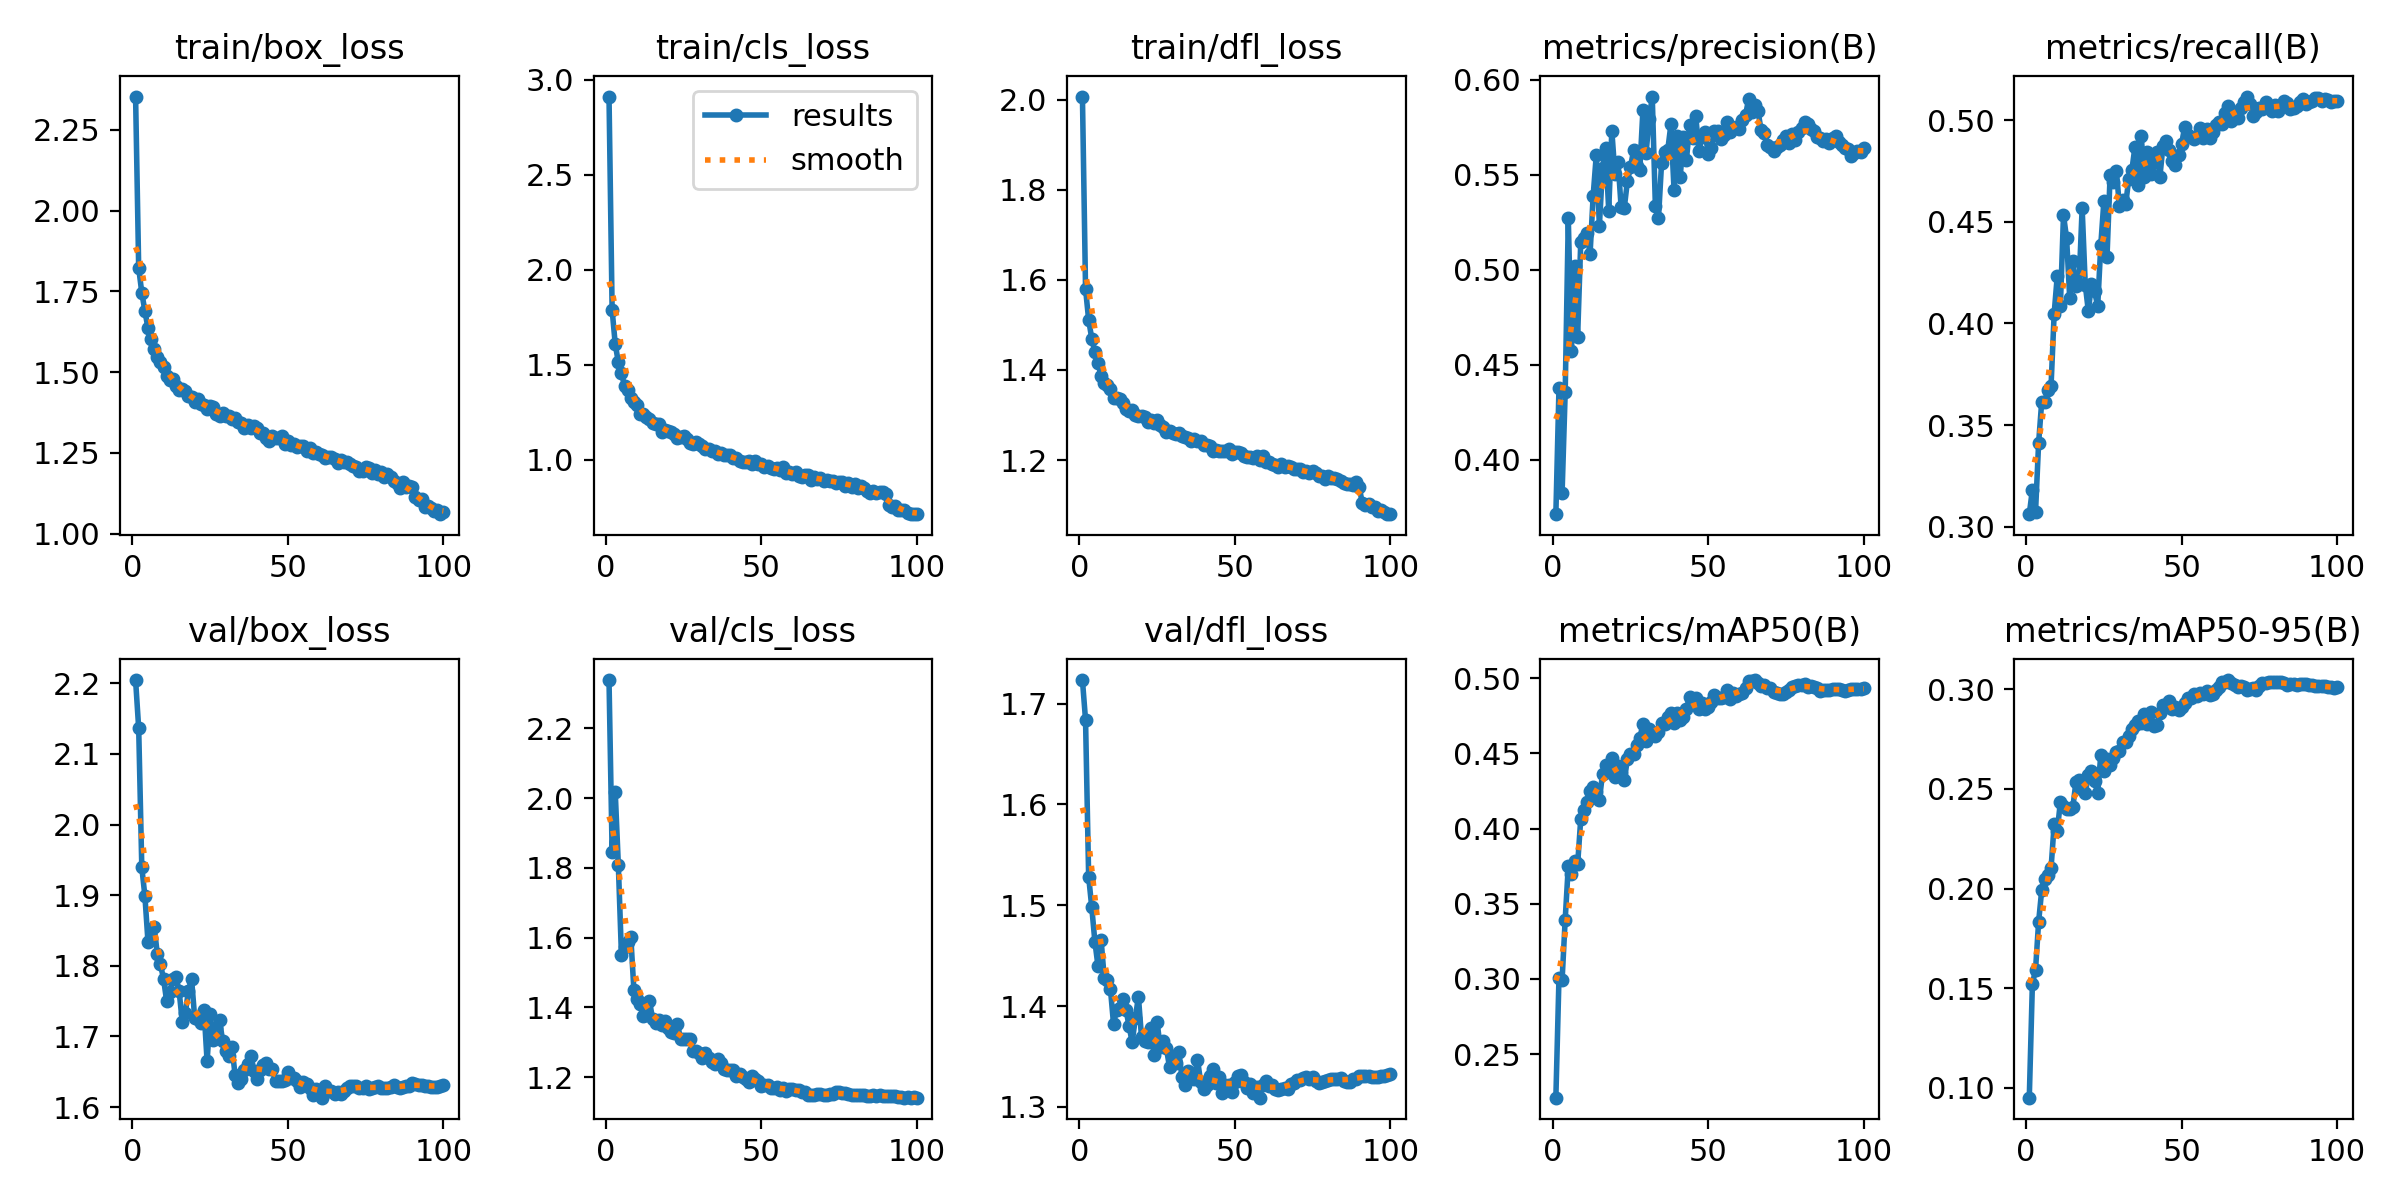

In [12]:
display(Image(filename = '/content/runs/detect/ship_detector_v8n_v1_26k/results.png'))

- Save Trained Weights to Google Drive

In [14]:
shutil.copy('/content/runs/detect/ship_detector_v8n_v1_26k/weights/best.pt',
            '/content/drive/MyDrive/ship_model_26k/best.pt')

'/content/drive/MyDrive/ship_model_26k/best.pt'

**Model Evaluation**